# Thống Kê Entropy (Tiếng Việt) - n_iter=5

Notebook này thu thập giá trị entropy từ các câu hỏi để xác định range của entropy phục vụ việc mapping.

## Cấu trúc:
- **Cells 1-4**: Phần thu thập dữ liệu - Chạy một lần để thu thập và lưu kết quả
- **Cells 5-7**: Phần phân tích - Có thể chạy độc lập bằng cách load CSV đã lưu

## Mục tiêu:
1. Load test queries từ file JSON
2. Thu thập entropy values sử dụng n=5 (trung bình qua 5 API calls để có stability tốt hơn)
3. Lưu kết quả vào CSV cho phân tích sau
4. Load kết quả đã lưu và thực hiện thống kê/visualization


## Cell 1: Setup và Import


In [2]:
import sys
import os
import json
from pathlib import Path

# Add project root to path
project_root = Path().absolute().parent.parent
sys.path.insert(0, str(project_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from typing import List, Dict

# Set matplotlib để xử lý font tiếng Việt
matplotlib.rcParams['font.family'] = 'DejaVu Sans'

print("Setup hoàn tất!")


Setup hoàn tất!


## Cell 2: Import Modules và Load Queries


In [3]:
from backend.models.adaptive_controller import AdaptiveController
from backend.config.config import get_config

# Khởi tạo adaptive controller
config = get_config()
controller = AdaptiveController(
    k_min=config.adaptive.k_min,
    k_max=config.adaptive.k_max
)

# Load test queries từ JSON
queries_file = Path("test_queries_vi.json")
with open(queries_file, 'r', encoding='utf-8') as f:
    test_queries = json.load(f)

# Flatten queries thành list với categories
all_queries = []
for category, queries in test_queries.items():
    for query in queries:
        all_queries.append({
            'query': query,
            'difficulty': category
        })

print(f"Đã load {len(all_queries)} queries")
print(f"  - Dễ: {len([q for q in all_queries if q['difficulty'] == 'dễ'])}")
print(f"  - Trung bình: {len([q for q in all_queries if q['difficulty'] == 'trung_bình'])}")
print(f"  - Khó: {len([q for q in all_queries if q['difficulty'] == 'khó'])}")
print(f"\nSử dụng n_iterations = 5 để có trung bình tốt hơn và stability cao hơn")


Đã load 101 queries
  - Dễ: 34
  - Trung bình: 34
  - Khó: 33

Sử dụng n_iterations = 5 để có trung bình tốt hơn và stability cao hơn


## Cell 3: Thu thập Entropy Data (n=5)


In [4]:
def collect_entropy_data(queries: List[Dict], language: str = "vi", n_iterations: int = 5) -> pd.DataFrame:
    """
    Thu thập entropy values từ các queries.
    Sử dụng n_iterations=5 để trung bình qua nhiều API calls cho stability tốt hơn.
    
    Returns:
        DataFrame với columns: sample_id, query, difficulty, entropy, entropy_std, n_iterations
    """
    results = []
    
    print(f"Bắt đầu thu thập entropy với n_iterations={n_iterations}...")
    print(f"Tổng số queries: {len(queries)}\n")
    
    for idx, item in enumerate(queries, 1):
        query = item['query']
        difficulty = item['difficulty']
        
        print(f"[{idx}/{len(queries)}] {difficulty}: {query[:50]}...")
        
        try:
            # Chạy adaptive controller để lấy entropy
            k_determined, metadata = controller.decide(
                query=query,
                language=language,
                n=n_iterations
            )
            
            avg_entropy = metadata.get('average_entropy', 0.0)
            entropy_std = metadata.get('entropy_std', 0.0)
            
            results.append({
                'sample_id': idx,
                'query': query,
                'difficulty': difficulty,
                'entropy': avg_entropy,
                'entropy_std': entropy_std,
                'k_determined': k_determined,
                'n_iterations': n_iterations
            })
            
        except Exception as e:
            print(f"    LỖI: {str(e)}")
            # Vẫn lưu record với lỗi
            results.append({
                'sample_id': idx,
                'query': query,
                'difficulty': difficulty,
                'entropy': None,
                'entropy_std': None,
                'k_determined': None,
                'n_iterations': n_iterations,
                'error': str(e)
            })
            continue
    
    return pd.DataFrame(results)

# Thu thập dữ liệu với n=5
df_entropy = collect_entropy_data(all_queries, language="vi", n_iterations=5)

print(f"\n✓ Đã thu thập {len(df_entropy)} samples")
df_entropy.head(10)


Bắt đầu thu thập entropy với n_iterations=5...
Tổng số queries: 101

[1/101] dễ: python là gì?...
[2/101] dễ: git là gì?...
[3/101] dễ: ai là gì?...
[4/101] dễ: machine learning là gì?...
[5/101] dễ: deep learning là gì?...
[6/101] dễ: neural network là gì?...
[7/101] dễ: gan là gì?...
[8/101] dễ: transformer là gì?...
[9/101] dễ: cơ sở dữ liệu là gì?...
[10/101] dễ: thuật toán là gì?...
[11/101] dễ: java là gì?...
[12/101] dễ: javascript là gì?...
[13/101] dễ: html là gì?...
[14/101] dễ: css là gì?...
[15/101] dễ: sql là gì?...
[16/101] dễ: api là gì?...
[17/101] dễ: json là gì?...
[18/101] dễ: xml là gì?...
[19/101] dễ: http là gì?...
[20/101] dễ: https là gì?...
[21/101] dễ: tcp là gì?...
[22/101] dễ: ip là gì?...
[23/101] dễ: dns là gì?...
[24/101] dễ: cloud là gì?...
[25/101] dễ: docker là gì?...
[26/101] dễ: kubernetes là gì?...
[27/101] dễ: linux là gì?...
[28/101] dễ: windows là gì?...
[29/101] dễ: macos là gì?...
[30/101] dễ: ios là gì?...
[31/101] dễ: android là gì?...
[32/10

,sample_id,query,difficulty,entropy,entropy_std,k_determined,n_iterations
0,1,python là gì?,dễ,0.234314,0.0,0,5
1,2,git là gì?,dễ,0.245527,0.0,0,5
2,3,ai là gì?,dễ,0.240735,0.0,0,5
3,4,machine learning là gì?,dễ,0.223856,0.0,0,5
4,5,deep learning là gì?,dễ,0.271994,0.0,0,5
5,6,neural network là gì?,dễ,0.269218,0.0,0,5
6,7,gan là gì?,dễ,0.288456,0.0,0,5
7,8,transformer là gì?,dễ,0.269949,0.0,0,5
8,9,cơ sở dữ liệu là gì?,dễ,0.250677,0.0,0,5
9,10,thuật toán là gì?,dễ,0.244291,0.0,0,5


## Cell 4: Lưu Kết Quả vào CSV


In [5]:
# Lưu kết quả vào CSV
csv_file = "entropy_analysis_results_vi.csv"
df_entropy.to_csv(csv_file, index=False)
print(f"✓ Kết quả đã lưu vào: {csv_file}")
print(f"Tổng số samples: {len(df_entropy)}")
df_entropy.head(10)


✓ Kết quả đã lưu vào: entropy_analysis_results_vi.csv
Tổng số samples: 101


,sample_id,query,difficulty,entropy,entropy_std,k_determined,n_iterations
0,1,python là gì?,dễ,0.234314,0.0,0,5
1,2,git là gì?,dễ,0.245527,0.0,0,5
2,3,ai là gì?,dễ,0.240735,0.0,0,5
3,4,machine learning là gì?,dễ,0.223856,0.0,0,5
4,5,deep learning là gì?,dễ,0.271994,0.0,0,5
5,6,neural network là gì?,dễ,0.269218,0.0,0,5
6,7,gan là gì?,dễ,0.288456,0.0,0,5
7,8,transformer là gì?,dễ,0.269949,0.0,0,5
8,9,cơ sở dữ liệu là gì?,dễ,0.250677,0.0,0,5
9,10,thuật toán là gì?,dễ,0.244291,0.0,0,5


## Cell 5: Đọc Kết Quả

**Lưu ý:** Nếu bạn đã chạy xong phần thu thập dữ liệu (Cell 3) và đã lưu kết quả, bạn có thể bỏ qua Cells 1-4 và bắt đầu từ cell này để load kết quả đã lưu.


In [6]:
# Đọc kết quả từ file CSV
csv_file = "entropy_analysis_results_vi.csv"
df_entropy = pd.read_csv(csv_file)

print(f"✓ Đã load {len(df_entropy)} samples từ {csv_file}")
print(f"\nXem trước dữ liệu:")
df_entropy.head(10)


✓ Đã load 101 samples từ entropy_analysis_results_vi.csv

Xem trước dữ liệu:


,sample_id,query,difficulty,entropy,entropy_std,k_determined,n_iterations
0,1,python là gì?,dễ,0.234314,0.0,0,5
1,2,git là gì?,dễ,0.245527,0.0,0,5
2,3,ai là gì?,dễ,0.240735,0.0,0,5
3,4,machine learning là gì?,dễ,0.223856,0.0,0,5
4,5,deep learning là gì?,dễ,0.271994,0.0,0,5
5,6,neural network là gì?,dễ,0.269218,0.0,0,5
6,7,gan là gì?,dễ,0.288456,0.0,0,5
7,8,transformer là gì?,dễ,0.269949,0.0,0,5
8,9,cơ sở dữ liệu là gì?,dễ,0.250677,0.0,0,5
9,10,thuật toán là gì?,dễ,0.244291,0.0,0,5


## Cell 6: Thống Kê Cơ Bản


In [7]:
# Lọc các samples hợp lệ
df_valid = df_entropy[df_entropy['entropy'].notna()]

print("=== THỐNG KÊ CƠ BẢN (n_iter=5) ===\n")
print("Thống kê tổng quan:")
print(df_valid['entropy'].describe())
print(f"\nRange: [{df_valid['entropy'].min():.4f}, {df_valid['entropy'].max():.4f}]")

print("\nTheo độ khó:")
print(df_valid.groupby('difficulty')['entropy'].describe())

print("\nEntropy Standard Deviation (qua 5 iterations):")
if 'entropy_std' in df_valid.columns:
    print(df_valid['entropy_std'].describe())

print("\nPercentiles:")
percentiles = [5, 10, 25, 50, 75, 90, 95, 99]
for p in percentiles:
    val = np.percentile(df_valid['entropy'], p)
    print(f"  {p}th percentile: {val:.4f}")


=== THỐNG KÊ CƠ BẢN (n_iter=5) ===

Thống kê tổng quan:
count    101.000000
mean       0.283842
std        0.046886
min        0.185592
25%        0.249286
50%        0.280204
75%        0.311734
max        0.399295
Name: entropy, dtype: float64

Range: [0.1856, 0.3993]

Theo độ khó:
            count      mean       std       min       25%       50%       75%  \
difficulty                                                                      
dễ           34.0  0.256481  0.042473  0.185592  0.230983  0.247407  0.282928   
khó          33.0  0.317299  0.041213  0.235378  0.289501  0.311957  0.342782   
trung_bình   34.0  0.278729  0.035956  0.209089  0.253107  0.275077  0.299119   

                 max  
difficulty            
dễ          0.360503  
khó         0.399295  
trung_bình  0.370324  

Entropy Standard Deviation (qua 5 iterations):
count    101.0
mean       0.0
std        0.0
min        0.0
25%        0.0
50%        0.0
75%        0.0
max        0.0
Name: entropy_std, dtype: 

## Cell 7: Scatter Plot Visualization


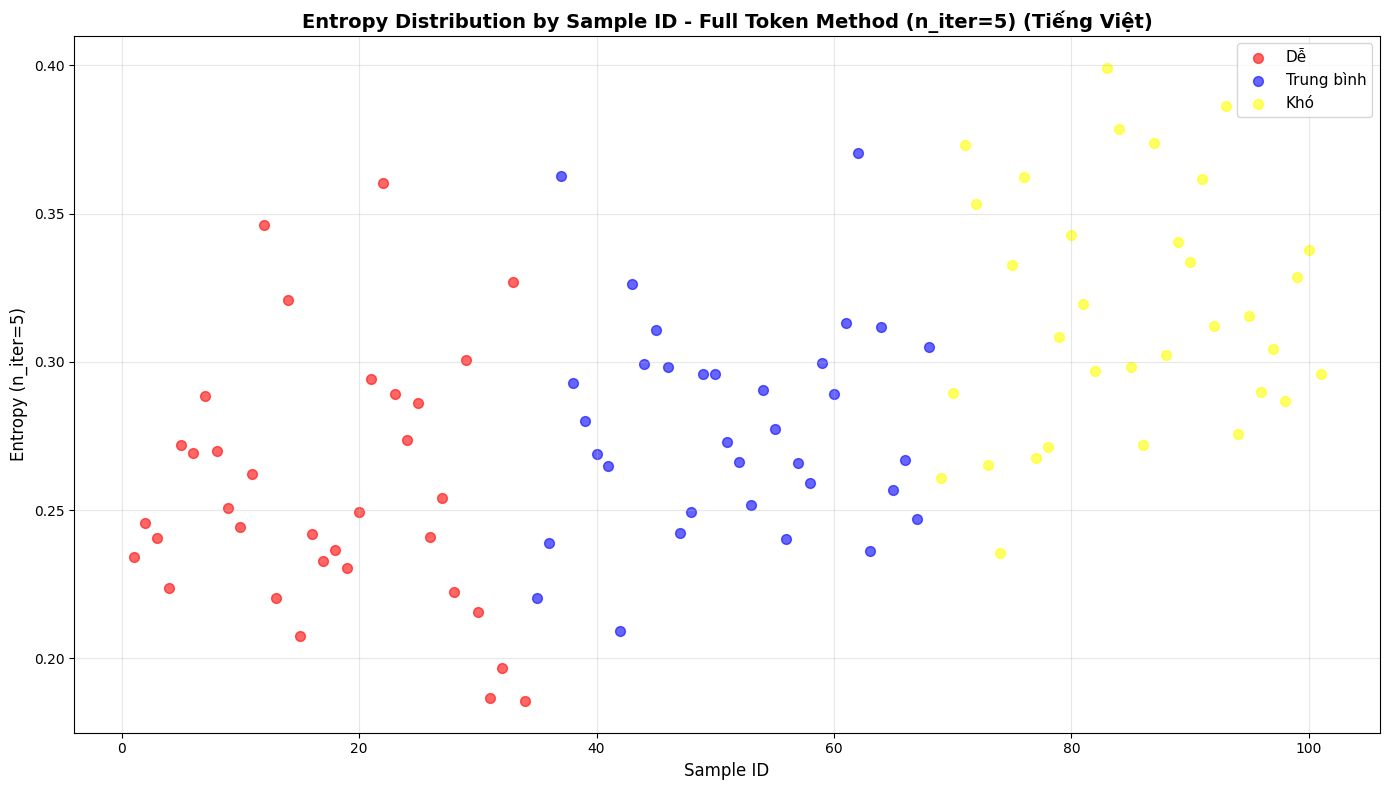

✓ Visualization hoàn tất
  - Đỏ: Câu hỏi dễ (34 samples)
  - Xanh: Câu hỏi trung bình (34 samples)
  - Vàng: Câu hỏi khó (33 samples)


In [8]:
# Lọc các samples hợp lệ
df_valid = df_entropy[df_entropy['entropy'].notna()]

# Color mapping: Red (dễ), Blue (trung_bình), Yellow (khó)
color_map = {
    'dễ': 'red',
    'trung_bình': 'blue',
    'khó': 'yellow'
}

# Tạo scatter plot
fig, ax = plt.subplots(figsize=(14, 8))

for difficulty in ['dễ', 'trung_bình', 'khó']:
    df_diff = df_valid[df_valid['difficulty'] == difficulty]
    if len(df_diff) > 0:
        ax.scatter(
            df_diff['sample_id'],
            df_diff['entropy'],
            c=color_map[difficulty],
            label=difficulty.capitalize().replace('_', ' '),
            alpha=0.6,
            s=50
        )

ax.set_xlabel('Sample ID', fontsize=12)
ax.set_ylabel('Entropy (n_iter=5)', fontsize=12)
ax.set_title('Entropy Distribution by Sample ID - Full Token Method (n_iter=5) (Tiếng Việt)', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"✓ Visualization hoàn tất")
print(f"  - Đỏ: Câu hỏi dễ ({len(df_valid[df_valid['difficulty'] == 'dễ'])} samples)")
print(f"  - Xanh: Câu hỏi trung bình ({len(df_valid[df_valid['difficulty'] == 'trung_bình'])} samples)")
print(f"  - Vàng: Câu hỏi khó ({len(df_valid[df_valid['difficulty'] == 'khó'])} samples)")
